# Decision Tree

Binary classification on California housing: `median_house_value > median`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

data_df = pd.read_csv("housing.csv")
data_df['total_bedrooms'] = data_df['total_bedrooms'].fillna(data_df['total_bedrooms'].median())
data_df = pd.get_dummies(data_df, columns=['ocean_proximity'], dtype=float)

threshold = data_df['median_house_value'].median()
y = (data_df['median_house_value'] > threshold).astype(int).to_numpy()
X = data_df.drop(columns=['median_house_value']).to_numpy()
feature_names = list(data_df.drop(columns=['median_house_value']).columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, shuffle=True, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(np.bincount(y_train), np.bincount(y_test))

(13828, 13) (6812, 13)
[6916 6912] [3407 3405]


## Baseline

Default `DecisionTreeClassifier`, no depth limit. Will overfit, but it's the reference.

In [2]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"Train acc: {accuracy_score(y_train, clf.predict(X_train)):.4f}")
print(f"Test acc:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Tree depth: {clf.get_depth()}")
print(f"Leaves: {clf.get_n_leaves()}")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Below', 'Above']))

Train acc: 1.0000
Test acc:  0.8467
Tree depth: 26
Leaves: 1393
[[2883  524]
 [ 520 2885]]
              precision    recall  f1-score   support

       Below       0.85      0.85      0.85      3407
       Above       0.85      0.85      0.85      3405

    accuracy                           0.85      6812
   macro avg       0.85      0.85      0.85      6812
weighted avg       0.85      0.85      0.85      6812



## Depth sweep

Train at increasing depth, plot train and test accuracy. Where the test curve flattens is roughly the right depth.

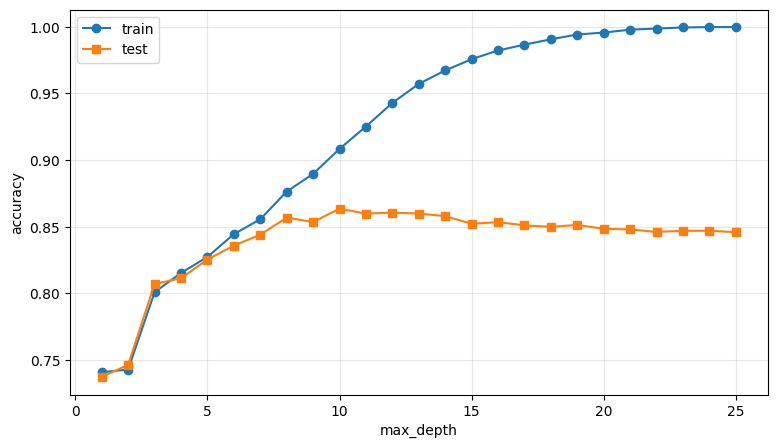

Best depth: 10, test acc: 0.8635


In [3]:
depths = list(range(1, 26))
train_acc, test_acc = [], []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, m.predict(X_train)))
    test_acc.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_acc, 'o-', label='train')
plt.plot(depths, test_acc, 's-', label='test')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_d = depths[int(np.argmax(test_acc))]
print(f"Best depth: {best_d}, test acc: {max(test_acc):.4f}")

## Splitting criterion

Compare three impurity measures at the best depth:

- **Gini**: $1 - \sum_i p_i^2$
- **Entropy**: $-\sum_i p_i \log_2 p_i$
- **Log loss**: same as cross-entropy

The split chosen minimizes the weighted child impurity. They usually give very similar trees.

In [4]:
for crit in ['gini', 'entropy', 'log_loss']:
    m = DecisionTreeClassifier(criterion=crit, max_depth=best_d, random_state=42)
    m.fit(X_train, y_train)
    tr = accuracy_score(y_train, m.predict(X_train))
    te = accuracy_score(y_test, m.predict(X_test))
    print(f"{crit:<10} train={tr:.4f} test={te:.4f}")

gini       train=0.9084 test=0.8635
entropy    train=0.9063 test=0.8533
log_loss   train=0.9063 test=0.8533


## Feature importance

Total impurity decrease per feature, normalized across the tree.

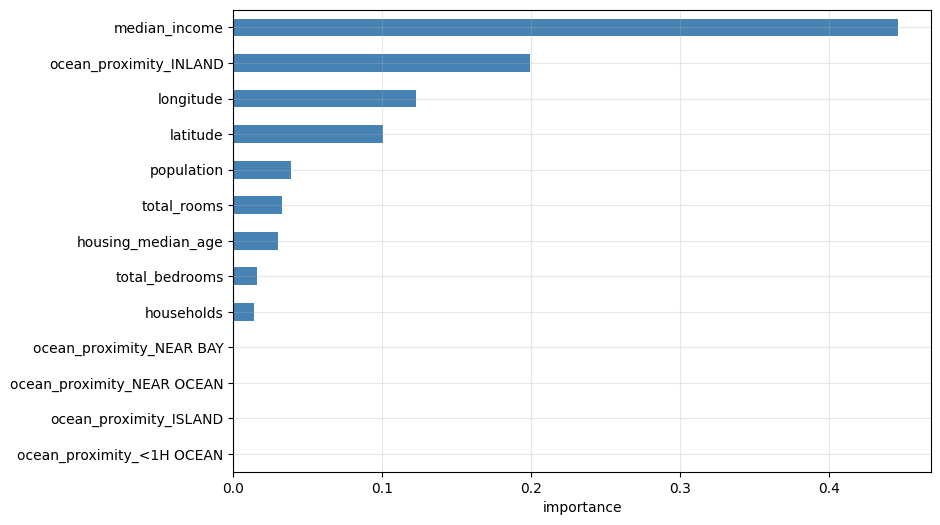

ocean_proximity_<1H OCEAN     0.000000
ocean_proximity_ISLAND        0.000000
ocean_proximity_NEAR OCEAN    0.000000
ocean_proximity_NEAR BAY      0.000078
households                    0.013808
total_bedrooms                0.015788
housing_median_age            0.029725
total_rooms                   0.032845
population                    0.038452
latitude                      0.100558
longitude                     0.122743
ocean_proximity_INLAND        0.199647
median_income                 0.446357
dtype: float64


In [5]:
best_tree = DecisionTreeClassifier(max_depth=best_d, random_state=42).fit(X_train, y_train)
importance = pd.Series(best_tree.feature_importances_, index=feature_names).sort_values()

plt.figure(figsize=(9, 6))
importance.plot(kind='barh', color='steelblue')
plt.xlabel('importance')
plt.grid(alpha=0.3)
plt.show()

print(importance)

## Tree visualization (shallow for readability)

Plot at `max_depth=3` so the splits are actually readable.

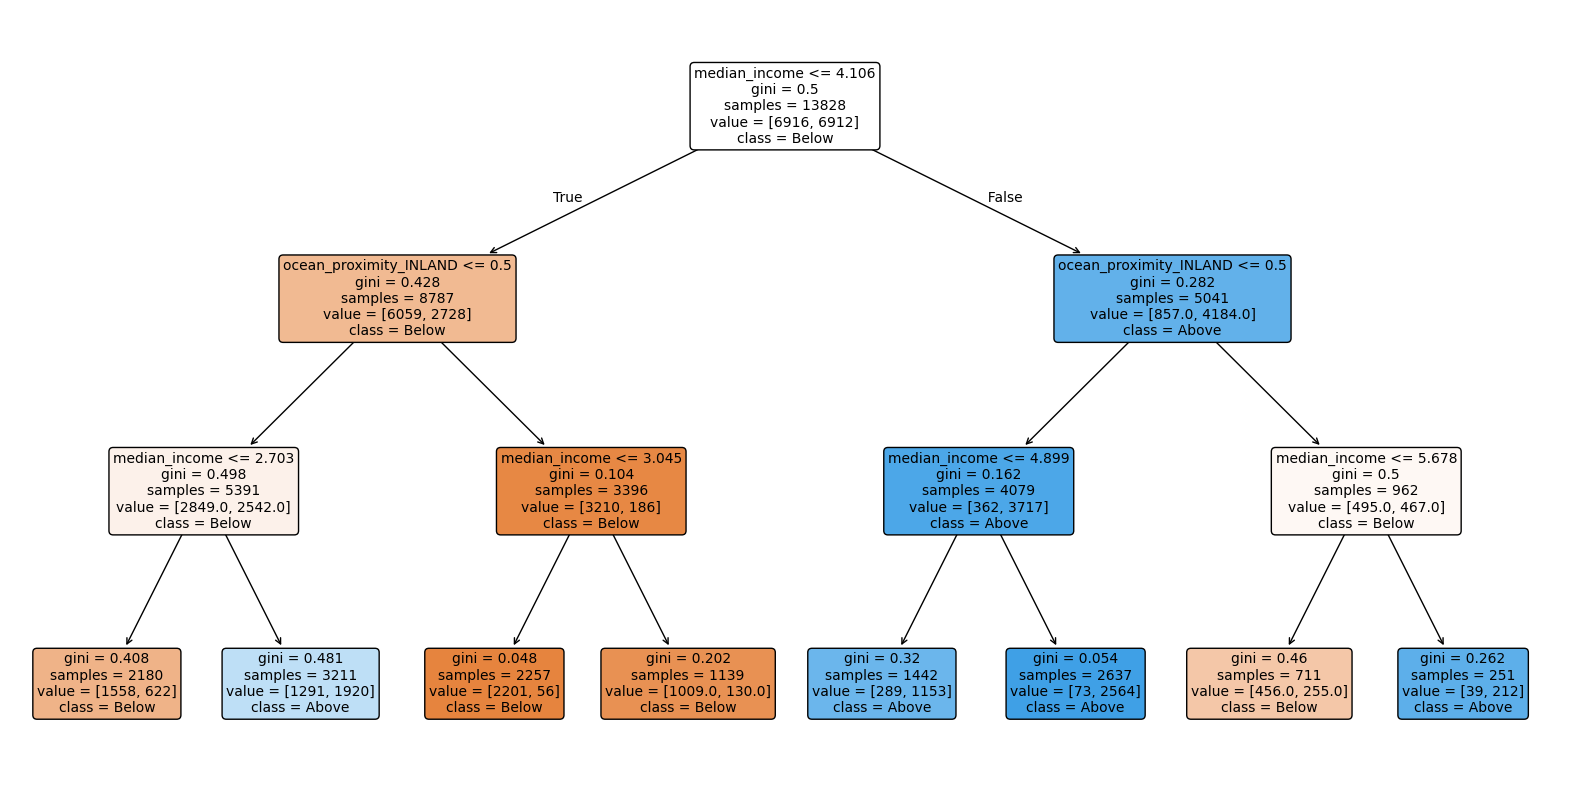

In [6]:
small = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)
plt.figure(figsize=(20, 10))
plot_tree(small, feature_names=feature_names, class_names=['Below', 'Above'],
          filled=True, rounded=True, fontsize=10)
plt.show()

## From-scratch (rice_ml)

My own decision tree. Subsampled because the split search isn't vectorized.

In [7]:
from rice_ml.supervised_ml import DecisionTreeClassifier as RMDecisionTree

rng_s = np.random.default_rng(42)
sub = rng_s.choice(len(X_train), 2000, replace=False)

dt_scratch = RMDecisionTree(max_depth=min(best_d, 6), criterion='gini', seed=42).fit(X_train[sub], y_train[sub])
print(f"from-scratch test acc: {dt_scratch.score(X_test, y_test):.4f}")
print(f"sklearn baseline acc:  {best_tree.score(X_test, y_test):.4f}")

from-scratch test acc: 0.8109
sklearn baseline acc:  0.8635
